In [14]:
import numpy as np
import geopandas as gpd
import pandas as pd
import rasterio
from rasterio.features import shapes
from shapely.geometry import shape
from glob import glob
import os

In [24]:
RASTER_PATH      = '../../data/output/gee_solution/warehouse_2025_cumulative_landsat30m.tif'
GROUNDTRUTH_PATH = '../../data/warehouse_polygon/warehouse_*.geojson'
WAREHOUSE_VALUE  = 1 

In [28]:
geojson_files = sorted(glob(GROUNDTRUTH_PATH))
print(f'Found GeoJSONs: {geojson_files}')

gdfs = []
for f in geojson_files:
    gdf = gpd.read_file(f)
    # Assign label based on filename
    label = 1 if 'warehouse' in os.path.basename(f).lower() and 'non' not in os.path.basename(f).lower() else 0
    gdf['label'] = label
    gdfs.append(gdf)

gt = gpd.GeoDataFrame(pd.concat(gdfs, ignore_index=True))

print(gt['label'].value_counts())

Found GeoJSONs: ['../../data/warehouse_polygon/warehouse_indie_aoi_1.geojson', '../../data/warehouse_polygon/warehouse_indie_aoi_2.geojson', '../../data/warehouse_polygon/warehouse_indie_aoi_3.geojson', '../../data/warehouse_polygon/warehouse_indie_aoi_4.geojson', '../../data/warehouse_polygon/warehouse_indie_aoi_5.geojson', '../../data/warehouse_polygon/warehouse_indie_aoi_6.geojson']
label
1    107
Name: count, dtype: int64


In [29]:
print(f'Ground truth CRS : {gt.crs}')
print(f'Ground truth rows: {len(gt)}')

Ground truth CRS : EPSG:4326
Ground truth rows: 107


In [27]:
gt = gpd.read_file(GROUNDTRUTH_PATH)
print(f'Ground truth CRS : {gt.crs}')
print(f'Ground truth rows: {len(gt)}')
gt.head()

DataSourceError: ../../data/warehouse_polygon/warehouse_*.geojson: No such file or directory

In [30]:
with rasterio.open(RASTER_PATH) as src:
    print(f'Raster CRS       : {src.crs}')
    print(f'Raster resolution: {src.res}')
    print(f'Raster shape     : {src.shape}')
    print(f'Unique values    : {np.unique(src.read(1))}')

Raster CRS       : EPSG:4326
Raster resolution: (0.00026949458523585647, 0.00026949458523585647)
Raster shape     : (2304, 3026)
Unique values    : [0 1]


In [31]:
# Polygonize the Classified Raster

with rasterio.open(RASTER_PATH) as src:
    image      = src.read(1).astype('uint8')
    transform  = src.transform
    raster_crs = src.crs

mask = (image == WAREHOUSE_VALUE).astype('uint8')

# shapes() yields (geometry_dict, pixel_value) for each connected region
results = [
    {'geometry': shape(geom), 'value': val}
    for geom, val in shapes(mask, mask=mask, transform=transform)
]

predicted = gpd.GeoDataFrame(results, crs=raster_crs)
print(f'Predicted warehouse polygons: {len(predicted)}')
predicted.head()

Predicted warehouse polygons: 938


,geometry,value
0,"POLYGON ((-86.51719 40.07816, -86.51719 40.077...",1.0
1,"POLYGON ((-86.44874 40.07762, -86.44874 40.077...",1.0
2,"POLYGON ((-86.47327 40.07762, -86.47327 40.077...",1.0
3,"POLYGON ((-86.51558 40.07735, -86.51558 40.076...",1.0
4,"POLYGON ((-86.51719 40.07654, -86.51719 40.076...",1.0


In [32]:
# Align CRS

if gt.crs != predicted.crs:
    print(f'Reprojecting ground truth from {gt.crs} to {predicted.crs}')
    gt = gt.to_crs(predicted.crs)
else:
    print('CRS already match — no reprojection needed')

# Match Predicted Polygons to Ground Truth

def best_iou_match(pred_geom, gt_gdf):
    """Return (best_iou, best_gt_idx) for a single predicted geometry."""
    best_iou = 0.0
    best_idx = None
    candidates = gt_gdf[gt_gdf.intersects(pred_geom)]
    for idx, row in candidates.iterrows():
        intersection = pred_geom.intersection(row.geometry).area
        union        = pred_geom.union(row.geometry).area
        iou = intersection / union if union > 0 else 0.0
        if iou > best_iou:
            best_iou = iou
            best_idx = idx
    return best_iou, best_idx

ious, matched_gt_ids = [], []

for _, pred_row in predicted.iterrows():
    iou, gt_idx = best_iou_match(pred_row.geometry, gt)
    ious.append(iou)
    matched_gt_ids.append(gt_idx)

predicted['iou']           = ious
predicted['matched_gt_id'] = matched_gt_ids
predicted.head()

CRS already match — no reprojection needed


,geometry,value,iou,matched_gt_id
0,"POLYGON ((-86.51719 40.07816, -86.51719 40.077...",1.0,0.0,NaN
1,"POLYGON ((-86.44874 40.07762, -86.44874 40.077...",1.0,0.0,NaN
2,"POLYGON ((-86.47327 40.07762, -86.47327 40.077...",1.0,0.0,NaN
3,"POLYGON ((-86.51558 40.07735, -86.51558 40.076...",1.0,0.0,NaN
4,"POLYGON ((-86.51719 40.07654, -86.51719 40.076...",1.0,0.0,NaN


In [33]:
# Compute metric

IOU_THRESHOLD = 0.5

tp_mask = predicted['iou'] >= IOU_THRESHOLD

TP = tp_mask.sum()
FP = (~tp_mask).sum()
FN = len(gt) - predicted['matched_gt_id'].nunique()

# safeguarding
if ((TP + FP) > 0):
    precision = TP / (TP + FP)
else:
    precision = 0.0

if ((TP + FN) > 0):
    recall    = TP / (TP + FN)
else:
    recall = 0
    
if (precision + recall) > 0:
    f1 = 2 * precision * recall / (precision + recall)
else:
    f1 = 0.0

if TP > 0:
    mean_iou  = predicted.loc[tp_mask, 'iou'].mean()
else:
    mean_iou = 0.0

print(f'IoU threshold : {IOU_THRESHOLD}')
print(f'TP            : {TP}')
print(f'FP            : {FP}')
print(f'FN            : {FN}')
print(f'Precision     : {precision:.3f}')
print(f'Recall        : {recall:.3f}')
print(f'F1            : {f1:.3f}')
print(f'Mean IoU (TP) : {mean_iou:.3f}')

predicted['iou'].describe()


IoU threshold : 0.5
TP            : 80
FP            : 858
FN            : 4
Precision     : 0.085
Recall        : 0.952
F1            : 0.157
Mean IoU (TP) : 0.648


count    938.000000
mean       0.064194
std        0.188993
min        0.000000
25%        0.000000
50%        0.000000
75%        0.000000
max        0.803852
Name: iou, dtype: float64

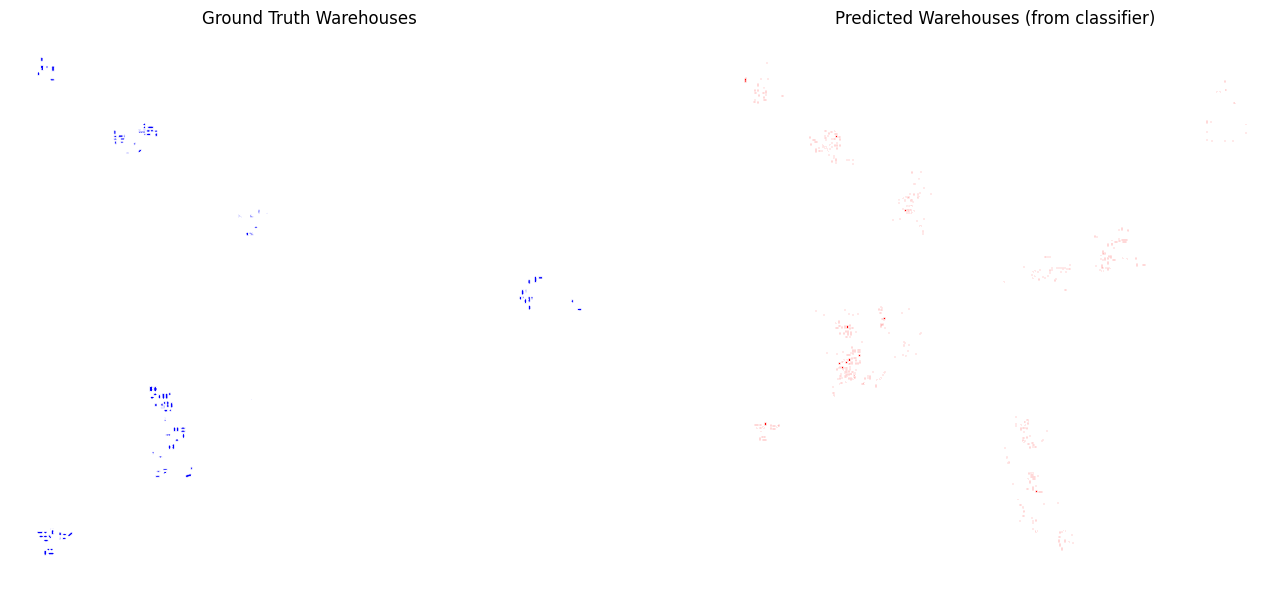

In [48]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Ground truth ---
gt.plot(ax=axes[0], color='blue', edgecolor='white', linewidth=0.5)
axes[0].set_title('Ground Truth Warehouses')
axes[0].set_axis_off()

# --- Predicted ---
predicted.plot(ax=axes[1], color='red', edgecolor='white', linewidth=0.5)
axes[1].set_title('Predicted Warehouses (from classifier)')
axes[1].set_axis_off()

plt.tight_layout()
plt.show()

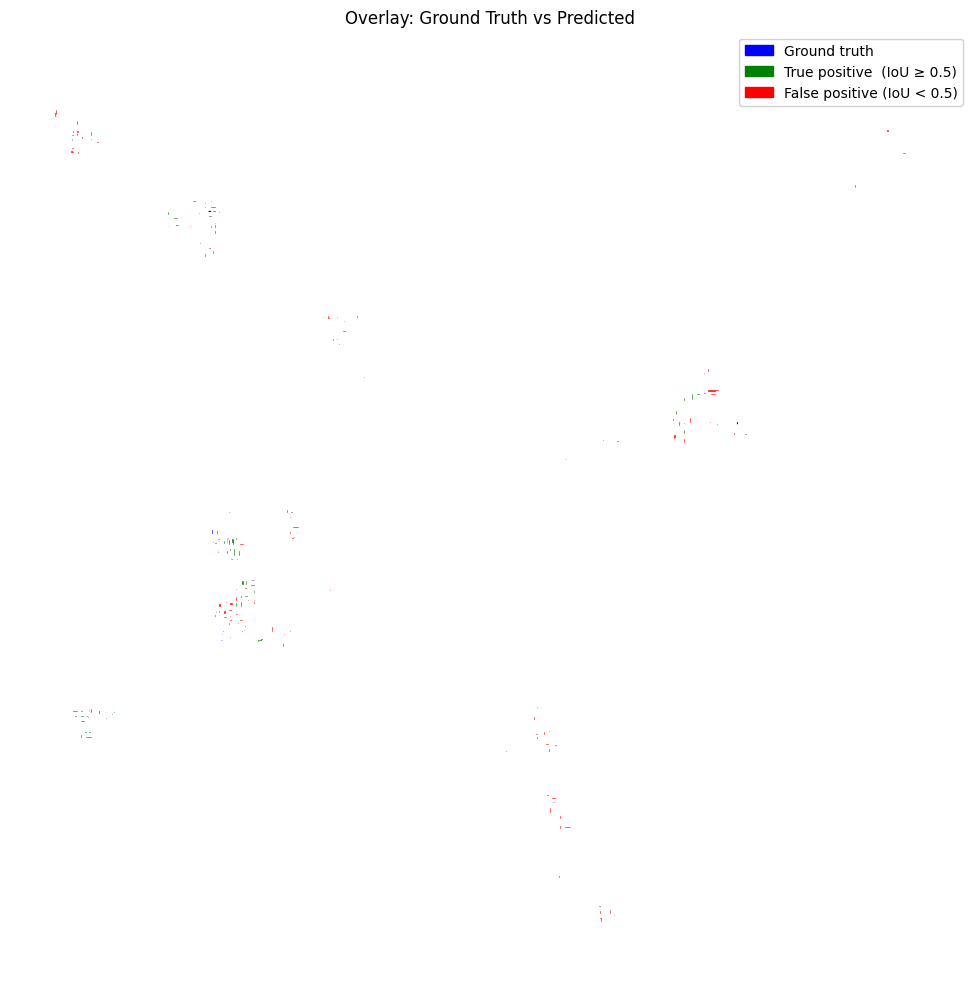

In [47]:
fig, ax = plt.subplots(figsize=(10, 10))

# Ground truth
gt.plot(ax=ax, color='blue', edgecolor='white', label='Ground truth')

# Predicted — color by TP/FP
tp_mask = predicted['iou'] >= IOU_THRESHOLD
predicted[tp_mask].plot(ax=ax,  color='green', edgecolor='white')
predicted[~tp_mask].plot(ax=ax, color='red',       edgecolor='white')

# Legend
legend_patches = [
    mpatches.Patch(color='blue', label='Ground truth'),
    mpatches.Patch(color='green', label=f'True positive  (IoU ≥ {IOU_THRESHOLD})'),
    mpatches.Patch(color='red', label=f'False positive (IoU < {IOU_THRESHOLD})'),
]
ax.legend(handles=legend_patches, loc='upper right', framealpha=0.9)
ax.set_title('Overlay: Ground Truth vs Predicted')
ax.set_axis_off()

plt.tight_layout()
plt.show()

In [49]:
predicted.to_file('../../data/output/eval/predicted_iou.gpkg', driver='GPKG')

In [50]:
gt.to_file("warehouse_gt.shp")